In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [11]:
df = pd.read_csv("/kaggle/input/datasets/huzdaria/laptop-pricing/laptop_pricing_dataset.csv")
print(df.shape)
df.head()

(238, 13)


,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    object 
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    object 
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  234 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       233 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 24.3+ KB


In [13]:
category_map = {1: "Gaming", 2: "Netbook", 3: "Notebook", 4: "Ultrabook", 5: "Workstation"}
gpu_map = {1: "AMD", 2: "Intel", 3: "NVidia"}
os_map = {1: "Windows", 2: "Linux"}

df["Category_label"] = df["Category"].map(category_map)
df["GPU_label"] = df["GPU"].map(gpu_map)
df["OS_label"] = df["OS"].map(os_map)

df.head()


,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price,Category_label,GPU_label,OS_label
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978,Ultrabook,Intel,Windows
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634,Notebook,AMD,Windows
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946,Notebook,AMD,Windows
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244,Ultrabook,Intel,Windows
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837,Ultrabook,Intel,Windows


In [14]:
df.describe()

,Unnamed: 0,Category,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
count,238.000000,238.000000,238.000000,238.000000,238.000000,234.000000,238.000000,238.000000,238.000000,233.000000,238.000000
mean,118.500000,3.205882,2.151261,1.058824,5.630252,37.269615,2.360084,7.882353,245.781513,1.862232,1462.344538
std,68.848868,0.776533,0.638282,0.235790,1.241787,2.971365,0.411393,2.482603,34.765316,0.494332,574.607699
min,0.000000,1.000000,1.000000,1.000000,3.000000,30.480000,1.200000,4.000000,128.000000,0.810000,527.000000
25%,59.250000,3.000000,2.000000,1.000000,5.000000,35.560000,2.000000,8.000000,256.000000,1.440000,1066.500000
50%,118.500000,3.000000,2.000000,1.000000,5.000000,38.100000,2.500000,8.000000,256.000000,1.870000,1333.000000
75%,177.750000,4.000000,3.000000,1.000000,7.000000,39.624000,2.700000,8.000000,256.000000,2.200000,1777.000000
max,237.000000,5.000000,3.000000,2.000000,7.000000,43.942000,2.900000,16.000000,256.000000,3.600000,3810.000000


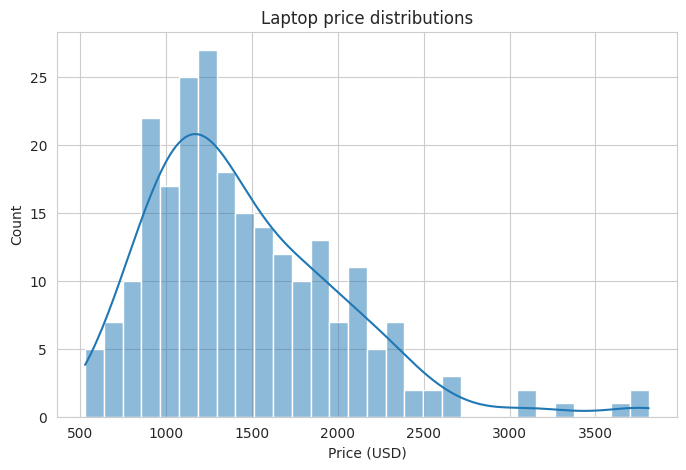

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Laptop price distributions")
plt.xlabel("Price (USD)")
plt.show()

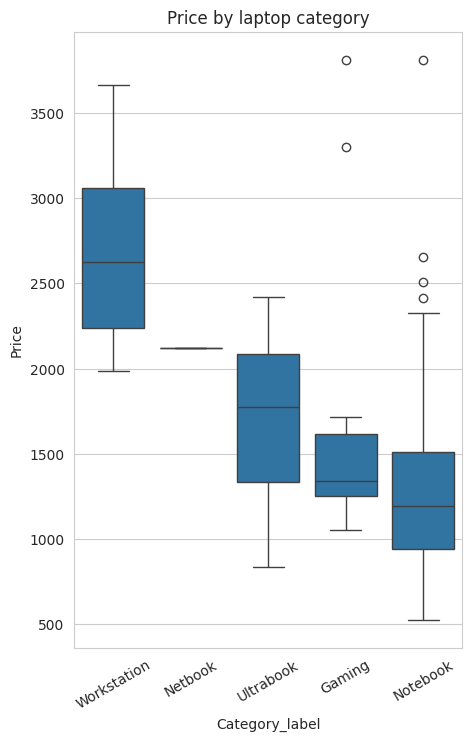

In [19]:
#Average price per category of laptop
plt.figure(figsize=(5,8))
order= df.groupby("Category_label")["Price"].median().sort_values(ascending=False).index
sns.boxplot(data=df,x="Category_label", y="Price", order=order)
plt.title("Price by laptop category")
plt.xticks(rotation=30)
plt.show()

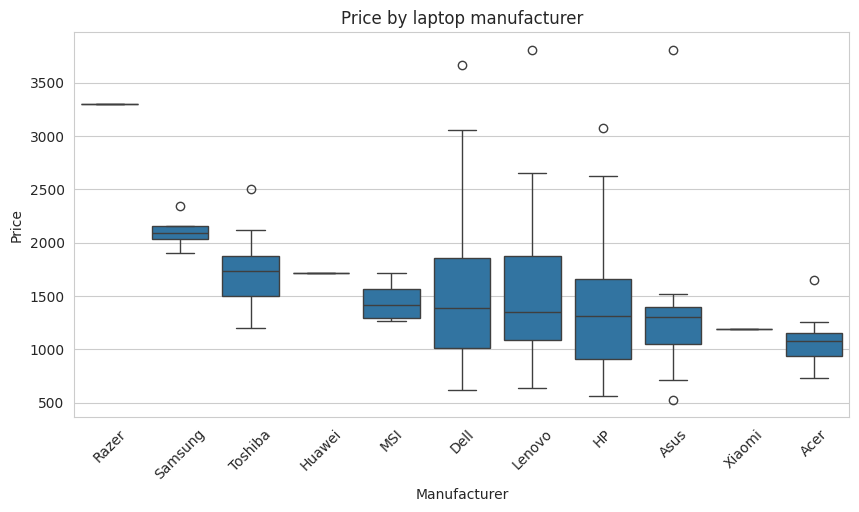

In [20]:
plt.figure(figsize=(10, 5))
order = df.groupby("Manufacturer")["Price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Manufacturer", y="Price", order=order)
plt.title("Price by laptop manufacturer")
plt.xticks(rotation=45)
plt.show()

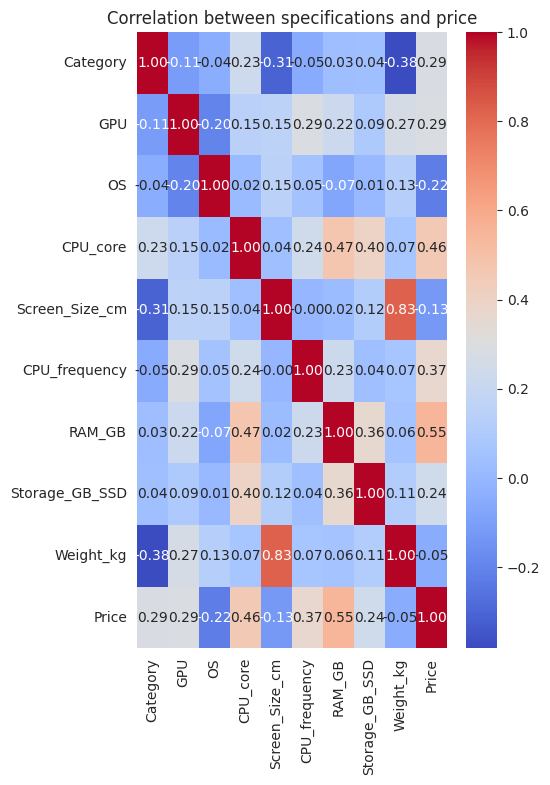

In [21]:
#Correlation matrix
numeric_cols=["Category", "GPU", "OS", "CPU_core", "Screen_Size_cm",
                 "CPU_frequency", "RAM_GB", "Storage_GB_SSD", "Weight_kg", "Price"]
plt.figure(figsize=(5,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between specifications and price")
plt.show()

In [22]:
df.isnull().sum()

Unnamed: 0        0
Manufacturer      0
Category          0
Screen            0
GPU               0
OS                0
CPU_core          0
Screen_Size_cm    4
CPU_frequency     0
RAM_GB            0
Storage_GB_SSD    0
Weight_kg         5
Price             0
Category_label    0
GPU_label         0
OS_label          0
dtype: int64

In [23]:
# If there is null values, we fill it with the median 
for col in ["Screen_Size_cm", "Weight_kg"]:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Fill {col} with median: {median_val}")

Fill Screen_Size_cm with median: 38.1
Fill Weight_kg with median: 1.87


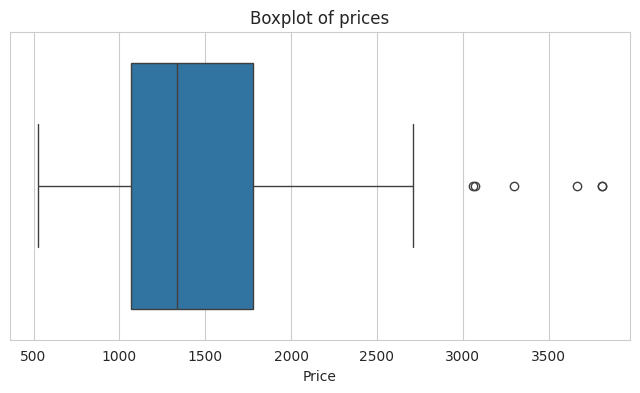

Min price: 527
Max price: 3810
count     238.000000
mean     1462.344538
std       574.607699
min       527.000000
25%      1066.500000
50%      1333.000000
75%      1777.000000
max      3810.000000
Name: Price, dtype: float64


In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Price"])
plt.title("Boxplot of prices")
plt.show()

print("Min price:", df["Price"].min())
print("Max price:", df["Price"].max())
print(df["Price"].describe())

In [25]:
# Variables we are going to use to predict Laptop's prices
features = [
    "Category", "GPU", "OS", "CPU_core",
    "Screen_Size_cm", "CPU_frequency", "RAM_GB",
    "Storage_GB_SSD", "Weight_kg"
]

# Target variable is price
target = "Price"

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (238, 9)
y shape: (238,)


In [26]:
#Split train and test 80-20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (190, 9)
Test: (48, 9)


****Train Lineal Regression Model for Laptop's price prediction****

In [31]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [33]:
#Evaluate regresion model
# Evaluate regression model
mae_lr = mean_absolute_error(y_test, lr_preds)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_preds))
r2_lr = r2_score(y_test, lr_preds)

print("=== Linear Regression ===")
print(f"MAE  (mean absolute error): ${mae_lr:.2f}")
print(f"RMSE (root mean squared error): ${rmse_lr:.2f}")
print(f"R2   (explained variance): {r2_lr:.3f}")

=== Linear Regression ===
MAE  (mean absolute error): $331.77
RMSE (root mean squared error): $412.09
R2   (explained variance): 0.263


****Train Random Forest Model****

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [36]:
# Evaluate Random Forest model
mae_rf = mean_absolute_error(y_test, rf_preds)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_preds))
r2_rf = r2_score(y_test, rf_preds)

print("=== Random Forest ===")
print(f"MAE  (mean absolute error): ${mae_rf:.2f}")
print(f"RMSE (root mean squared error): ${rmse_rf:.2f}")
print(f"R2   (explained variance): {r2_rf:.3f}")

=== Random Forest ===
MAE  (mean absolute error): $284.35
RMSE (root mean squared error): $372.45
R2   (explained variance): 0.398


In [37]:
# Compare both models side by side
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE ($)": [round(mae_lr, 2), round(mae_rf, 2)],
    "RMSE ($)": [round(rmse_lr, 2), round(rmse_rf, 2)],
    "R2": [round(r2_lr, 3), round(r2_rf, 3)]
})

comparison

,Model,MAE ($),RMSE ($),R2
0,Linear Regression,331.77,412.09,0.263
1,Random Forest,284.35,372.45,0.398


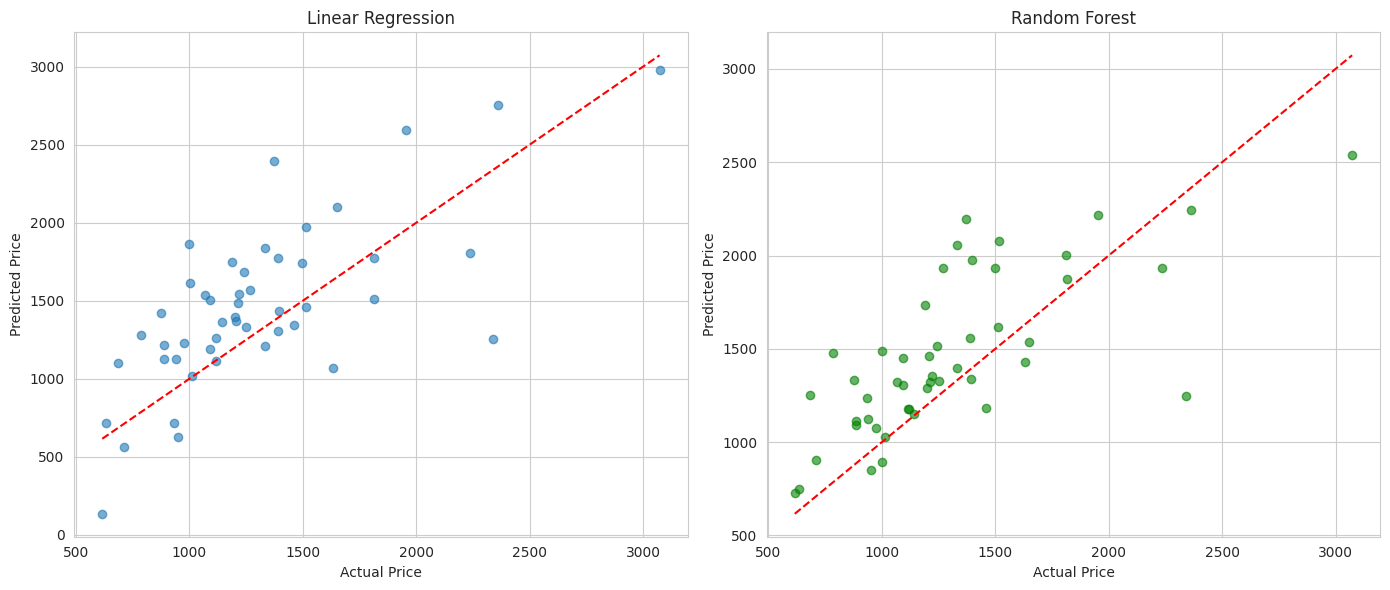

In [38]:
# Predicted vs actual price plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, lr_preds, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Linear Regression")

axes[1].scatter(y_test, rf_preds, alpha=0.6, color="green")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

In [39]:
import joblib

# Save the trained Random Forest model to disk
joblib.dump(rf_model, "laptop_price_model.pkl")

print("Model saved as laptop_price_model.pkl")

Model saved as laptop_price_model.pkl


In [40]:
def predict_laptop_price(category, gpu, os_type, cpu_core, screen_size_cm,
                          cpu_frequency, ram_gb, storage_gb_ssd, weight_kg,
                          model=rf_model):
    """
    Estimate the price of a laptop given its specifications.

    Parameters use the same encoding as the original dataset:
    - category: 1=Gaming, 2=Netbook, 3=Notebook, 4=Ultrabook, 5=Workstation
    - gpu: 1=AMD, 2=Intel, 3=NVidia
    - os_type: 1=Windows, 2=Linux
    - cpu_core: 3=i3, 5=i5, 7=i7
    """
    input_data = pd.DataFrame([{
        "Category": category,
        "GPU": gpu,
        "OS": os_type,
        "CPU_core": cpu_core,
        "Screen_Size_cm": screen_size_cm,
        "CPU_frequency": cpu_frequency,
        "RAM_GB": ram_gb,
        "Storage_GB_SSD": storage_gb_ssd,
        "Weight_kg": weight_kg
    }])

    predicted_price = model.predict(input_data)[0]
    return round(predicted_price, 2)

In [41]:
# Example: estimate the price of a gaming laptop
# Gaming, NVidia GPU, Windows, i7, 39.6cm screen, 2.8GHz, 16GB RAM, 512GB SSD, 2.3kg

estimated_price = predict_laptop_price(
    category=1,          # Gaming
    gpu=3,                # NVidia
    os_type=1,            # Windows
    cpu_core=7,            # i7
    screen_size_cm=39.6,
    cpu_frequency=2.8,
    ram_gb=16,
    storage_gb_ssd=512,
    weight_kg=2.3
)

print(f"Estimated price: ${estimated_price}")

Estimated price: $2159.5


In [43]:
def interactive_price_estimator():
    print("=== Laptop Price Estimator ===\n")
    category = int(input("Category (1=Gaming, 2=Netbook, 3=Notebook, 4=Ultrabook, 5=Workstation): "))
    gpu = int(input("GPU (1=AMD, 2=Intel, 3=NVidia): "))
    os_type = int(input("OS (1=Windows, 2=Linux): "))
    cpu_core = int(input("CPU core (3=i3, 5=i5, 7=i7): "))
    screen_size_cm = float(input("Screen size (cm): "))
    cpu_frequency = float(input("CPU frequency (GHz): "))
    ram_gb = float(input("RAM (GB): "))
    storage_gb_ssd = float(input("SSD storage (GB): "))
    weight_kg = float(input("Weight (kg): "))

    price = predict_laptop_price(category, gpu, os_type, cpu_core,
                                  screen_size_cm, cpu_frequency,
                                  ram_gb, storage_gb_ssd, weight_kg)

    print(f"\nEstimated price: ${price}")

# Uncomment to run interactively:
interactive_price_estimator()

=== Laptop Price Estimator ===



Category (1=Gaming, 2=Netbook, 3=Notebook, 4=Ultrabook, 5=Workstation):  2
GPU (1=AMD, 2=Intel, 3=NVidia):  1
OS (1=Windows, 2=Linux):  1
CPU core (3=i3, 5=i5, 7=i7):  3
Screen size (cm):  30
CPU frequency (GHz):  3
RAM (GB):  16
SSD storage (GB):  512
Weight (kg):  3



Estimated price: $2392.48
